# Architecture Ablation: LoRA vs Full Finetune

Both models trained on the same 90k split (the LoRA baseline's data). Only the architecture changes: LoRA adapters vs full fine-tuning. This isolates whether the quality gap in the main comparison came from less data or from the adapter approach.

In [8]:
import json
import pickle
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path("../../../..").resolve()
DATA_DIR = Path("data")
GLOBAL_MODEL_DIR = ROOT / "data" / "models" / "transformer_lora"
ABLATION_DIR = DATA_DIR / "finetune"
ABLATION_DIR.mkdir(parents=True, exist_ok=True)

PYTHON = sys.executable
SEED = 42

assert GLOBAL_MODEL_DIR.exists() and (GLOBAL_MODEL_DIR / "data_splits.pkl").exists(), (
    f"Global model not found at {GLOBAL_MODEL_DIR}. "
    f"Train it first:\n  python -m model.train --model transformer_lora "
    f"--data data/train_dataset_clean.csv --output {GLOBAL_MODEL_DIR} --train-subset 100000"
)

## 1. Baseline (global model)

In [9]:
if not (GLOBAL_MODEL_DIR / "evaluation_results.json").exists():
    !cd {ROOT} && {PYTHON} -m model.evaluate --model transformer_lora --model-dir {GLOBAL_MODEL_DIR}

with open(GLOBAL_MODEL_DIR / "evaluation_results.json") as f:
    results_baseline = json.load(f)

print(f"Baseline threshold: {results_baseline['best_threshold']:.2f}")
for m, v in results_baseline['quality_tuned'].items():
    print(f"  {m:15s}: {v:.4f}")

Baseline threshold: 0.49
  precision      : 0.8649
  recall         : 0.7320
  f1_score       : 0.7929
  pr_auc         : 0.8853


## 2. Train & Evaluate (full finetune, same data)

In [10]:
if not (ABLATION_DIR / "evaluation_results.json").exists():
    splits_path = GLOBAL_MODEL_DIR / "data_splits.pkl"

    with open(splits_path, "rb") as f:
        splits = pickle.load(f)
    print(f"Train: {len(splits['X_train'])}, Val: {len(splits['X_val'])}, Test: {len(splits['X_test'])}")
    print(f"Train toxicity rate: {splits['y_train'].mean():.2%}")

    !cd {ROOT} && {PYTHON} -m model.train --model transformer --data-splits {splits_path.resolve()} --output {ABLATION_DIR.resolve()}
    !cd {ROOT} && {PYTHON} -m model.evaluate --model transformer --model-dir {ABLATION_DIR.resolve()}
else:
    print(f"Results already exist in {ABLATION_DIR}, skipping.")

Train: 90000, Val: 10000, Test: 92061
Train toxicity rate: 20.06%
Loading data splits from /Users/ar.babkin/Desktop/Visual_Studio_IDE/GenAI-Safety-Fliter/data/models/transformer_lora/data_splits.pkl...
Train: 90000, Val: 10000, Test: 92061
Train toxicity rate: 20.06%
Device: mps
config.json: 100%|██████████████████████████████| 483/483 [00:00<00:00, 426kB/s]
tokenizer_config.json: 100%|██████████████████| 48.0/48.0 [00:00<00:00, 125kB/s]
vocab.txt: 232kB [00:00, 2.28MB/s]
tokenizer.json: 466kB [00:00, 3.34MB/s]
model.safetensors: 100%|█████████████████████| 268M/268M [00:10<00:00, 25.3MB/s]
Loading weights: 100%|█████████████████████| 100/100 [00:00<00:00, 13072.07it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
voc

## 3. Load Results

In [11]:
with open(ABLATION_DIR / "evaluation_results.json") as f:
    results_ablation = json.load(f)

print("Baseline results loaded:", list(results_baseline.keys()))
print("Ablation results loaded:", list(results_ablation.keys()))

Baseline results loaded: ['quality', 'confusion_matrix', 'latency', 'throughput_samples_per_sec', 'peak_memory_mb', 'quality_tuned', 'best_threshold', 'confusion_matrix_tuned']
Ablation results loaded: ['quality', 'confusion_matrix', 'latency', 'throughput_samples_per_sec', 'peak_memory_mb', 'quality_tuned', 'best_threshold', 'confusion_matrix_tuned']


## 4. Comparison

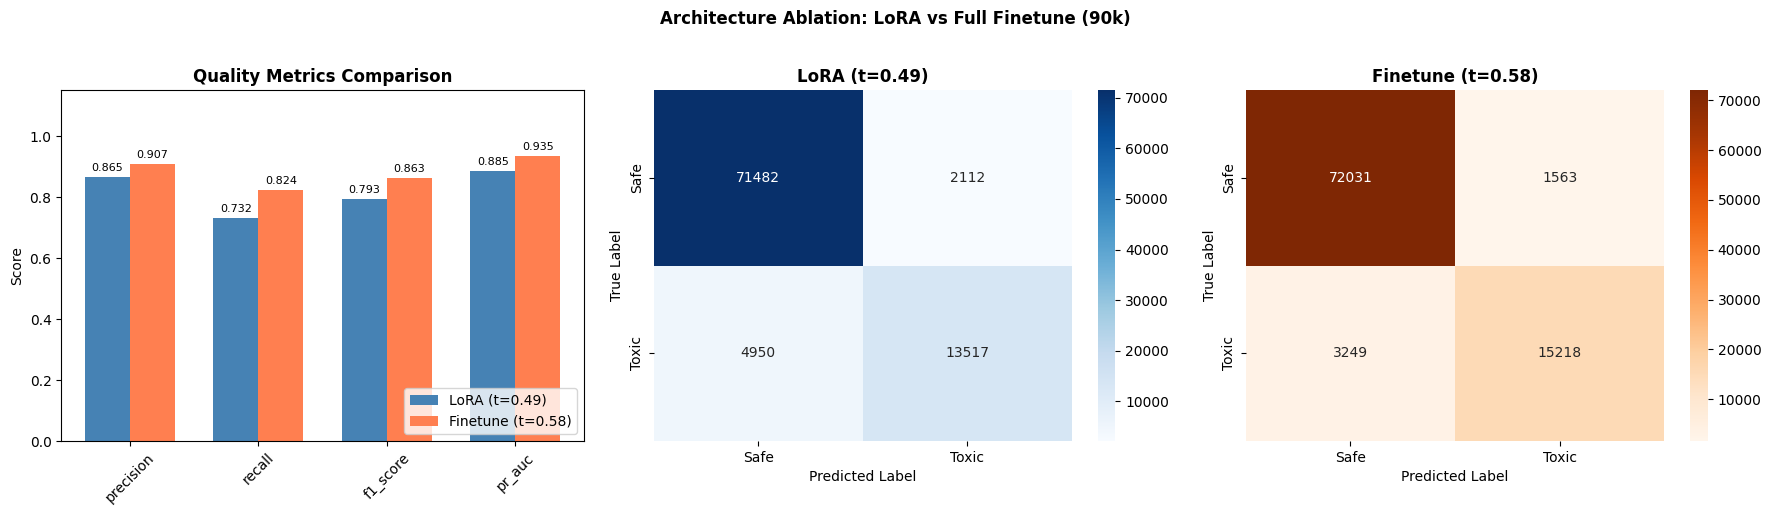


ARCHITECTURE ABLATION SUMMARY (tuned thresholds)
Metric            LoRA (90k) Finetune (90k)      Delta
------------------------------------------------------
precision             0.8649         0.9069    +0.0420
recall                0.7320         0.8241    +0.0921
f1_score              0.7929         0.8635    +0.0706
pr_auc                0.8853         0.9354    +0.0501
------------------------------------------------------
Threshold               0.49           0.58
Train size            90,000         90,000
Toxic ratio             ~20%           ~20%


In [12]:
metrics_names = ['precision', 'recall', 'f1_score', 'pr_auc']
base_vals = [results_baseline['quality_tuned'][m] for m in metrics_names]
abl_vals = [results_ablation['quality_tuned'][m] for m in metrics_names]
t_base = results_baseline['best_threshold']
t_abl = results_ablation['best_threshold']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(metrics_names))
width = 0.35
bars1 = axes[0].bar(x - width/2, base_vals, width,
                    label=f'LoRA (t={t_base:.2f})', color='steelblue')
bars2 = axes[0].bar(x + width/2, abl_vals, width,
                    label=f'Finetune (t={t_abl:.2f})', color='coral')
axes[0].set_ylabel('Score')
axes[0].set_title('Quality Metrics Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names, rotation=45)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1.15)
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.3f}',
                 ha='center', fontsize=8)

cm_base = np.array(results_baseline['confusion_matrix_tuned'])
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Safe', 'Toxic'], yticklabels=['Safe', 'Toxic'])
axes[1].set_title(f'LoRA (t={t_base:.2f})', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

cm_abl = np.array(results_ablation['confusion_matrix_tuned'])
sns.heatmap(cm_abl, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Safe', 'Toxic'], yticklabels=['Safe', 'Toxic'])
axes[2].set_title(f'Finetune (t={t_abl:.2f})', fontweight='bold')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.suptitle('Architecture Ablation: LoRA vs Full Finetune (90k)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("ARCHITECTURE ABLATION SUMMARY (tuned thresholds)")
print("=" * 70)
print(f"{'Metric':<15} {'LoRA (90k)':>12} {'Finetune (90k)':>14} {'Delta':>10}")
print("-" * 54)
for m in metrics_names:
    bv = results_baseline['quality_tuned'][m]
    av = results_ablation['quality_tuned'][m]
    delta = av - bv
    print(f"{m:<15} {bv:>12.4f} {av:>14.4f} {delta:>+10.4f}")
print("-" * 54)
print(f"{'Threshold':<15} {t_base:>12.2f} {t_abl:>14.2f}")
print(f"{'Train size':<15} {'90,000':>12} {'90,000':>14}")
print(f"{'Toxic ratio':<15} {'~20%':>12} {'~20%':>14}")

## 5. Interpretation

Full finetune beats LoRA by **+7.1pp F1** on the same 90k data — a purely architectural gap. The recall difference is especially large (+9.2pp), meaning LoRA misses significantly more toxic examples even with identical training data.

This breaks down the main comparison gap (LoRA 90k vs full finetune 331k = 13.9pp F1) roughly in half:
- ~7pp from architecture (LoRA only updates 1% of parameters)
- ~7pp from data size (90k vs 331k for full finetune)

LoRA pays a quality cost on both fronts, not just one.